# Limpieza y transformación de datos


### CSV Customer Flight Activity


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
df_activity = pd.read_csv('files/Customer flight Activity.csv', index_col = 0)
df_activity.head()

,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
Loyalty Number,,,,,,,,,
100018,2017,1,3,0,3,1521,152.0,0,0
100102,2017,1,10,4,14,2030,203.0,0,0
100140,2017,1,6,0,6,1200,120.0,0,0
100214,2017,1,0,0,0,0,0.0,0,0
100272,2017,1,0,0,0,0,0.0,0,0


In [21]:
# unir columnas year-month

df_activity["date"] = pd.to_datetime(
    df_activity["Year"].astype(str) + "-" + df_activity["Month"].astype(str) + "-01"
)


In [30]:
columna = df_activity.pop("date")

In [31]:

df_activity.insert(2, "date", columna)

In [ ]:
#Elimino columna Month
df_activity = df_activity.drop(columns="Month")

In [38]:
df_activity[df_activity.duplicated()]


,Year,date,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
Loyalty Number,,,,,,,,,
100272,2017,2017-01-01,0,0,0,0,0.0,0,0
100301,2017,2017-01-01,0,0,0,0,0.0,0,0
100364,2017,2017-01-01,0,0,0,0,0.0,0,0
100380,2017,2017-01-01,0,0,0,0,0.0,0,0
100504,2017,2017-01-01,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...
999891,2018,2018-12-01,0,0,0,0,0.0,0,0
999902,2018,2018-12-01,0,0,0,0,0.0,0,0
999911,2018,2018-12-01,0,0,0,0,0.0,0,0


In [35]:
df_activity

,Year,date,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
Loyalty Number,,,,,,,,,
100018,2017,2017-01-01,3,0,3,1521,152.0,0,0
100102,2017,2017-01-01,10,4,14,2030,203.0,0,0
100140,2017,2017-01-01,6,0,6,1200,120.0,0,0
100214,2017,2017-01-01,0,0,0,0,0.0,0,0
100272,2017,2017-01-01,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...
999902,2018,2018-12-01,0,0,0,0,0.0,0,0
999911,2018,2018-12-01,0,0,0,0,0.0,0,0
999940,2018,2018-12-01,3,0,3,1233,123.0,0,0


In [39]:
df_activity.isnull().sum() / len(df_activity) * 100

Year                           0.0
date                           0.0
Flights Booked                 0.0
Flights with Companions        0.0
Total Flights                  0.0
Distance                       0.0
Points Accumulated             0.0
Points Redeemed                0.0
Dollar Cost Points Redeemed    0.0
dtype: float64

In [23]:
df_activity.info()

<class 'pandas.DataFrame'>
Index: 405624 entries, 100018 to 999986
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Year                         405624 non-null  int64         
 1   Month                        405624 non-null  int64         
 2   Flights Booked               405624 non-null  int64         
 3   Flights with Companions      405624 non-null  int64         
 4   Total Flights                405624 non-null  int64         
 5   Distance                     405624 non-null  int64         
 6   Points Accumulated           405624 non-null  float64       
 7   Points Redeemed              405624 non-null  int64         
 8   Dollar Cost Points Redeemed  405624 non-null  int64         
 9   date                         405624 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(8)
memory usage: 34.0 MB


### CSV customer loyalty history

In [10]:
df_loyalty = pd.read_csv('files/Customer Loyalty History.csv', index_col = 0)
df_loyalty.head()

,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
Loyalty Number,,,,,,,,,,,,,,,
480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [12]:
df_loyalty.info()

<class 'pandas.DataFrame'>
Index: 16737 entries, 480934 to 652627
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             16737 non-null  str    
 1   Province            16737 non-null  str    
 2   City                16737 non-null  str    
 3   Postal Code         16737 non-null  str    
 4   Gender              16737 non-null  str    
 5   Education           16737 non-null  str    
 6   Salary              12499 non-null  float64
 7   Marital Status      16737 non-null  str    
 8   Loyalty Card        16737 non-null  str    
 9   CLV                 16737 non-null  float64
 10  Enrollment Type     16737 non-null  str    
 11  Enrollment Year     16737 non-null  int64  
 12  Enrollment Month    16737 non-null  int64  
 13  Cancellation Year   2067 non-null   float64
 14  Cancellation Month  2067 non-null   float64
dtypes: float64(4), int64(2), str(9)
memory usage: 2.0 MB


In [ ]:
#Comprobación de duplicados
df_loyalty.duplicated().sum()




np.int64(0)

In [52]:
# unir columnas enrollment year-month

df_loyalty["Enrollment Date"] = pd.to_datetime(
    df_loyalty["Enrollment Year"].astype(str) + "-" + df_loyalty["Enrollment Month"].astype(str) + "-01"
)

In [53]:
columna2 = df_loyalty.pop("Enrollment Date")
df_loyalty.insert(11, "Enrollment Date", columna2)

In [56]:
# unir columnas cancellation year-month

#primero las pasamos a int
columnas_cancellation = ['Cancellation Year', 'Cancellation Month']
df_loyalty[columnas_cancellation] = df_loyalty[columnas_cancellation].astype("Int64")

df_loyalty["Cancellation Date"] = pd.to_datetime(
    df_loyalty["Cancellation Year"].astype(str) + "-" + df_loyalty["Cancellation Month"].astype(str) + "-01"
)

In [58]:
#eliminar las columnas month

df_loyalty = df_loyalty.drop(columns=["Enrollment Month",'Cancellation Month'])

In [59]:
df_loyalty

,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Date,Enrollment Year,Cancellation Year,Cancellation Date
Loyalty Number,,,,,,,,,,,,,,,
480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016-02-01,2016,<NA>,NaT
549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016-03-01,2016,<NA>,NaT
429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014-07-01,2014,2018,2018-01-01
608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013-02-01,2013,<NA>,NaT
530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014-10-01,2014,<NA>,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012-12-01,2012,<NA>,NaT
680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014-09-01,2014,<NA>,NaT
776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014-03-01,2014,<NA>,NaT


#### Gestión de nulos salary

In [83]:
# Copia columna original

salary_original = df_loyalty["Salary"].copy()

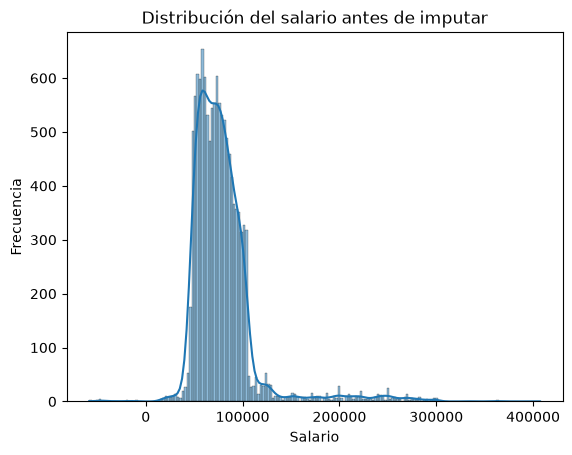

In [87]:
#Antes de imputar los nulos, vemos la distribución

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_loyalty["Salary"], kde=True)

plt.title("Distribución del salario antes de imputar")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

In [89]:
columnas_imputacion = ['Salary', 'CLV']
imputer_knn = KNNImputer(n_neighbors=5)
df_loyalty[columnas_imputacion] = imputer_knn.fit_transform(
    df_loyalty[columnas_imputacion]
)

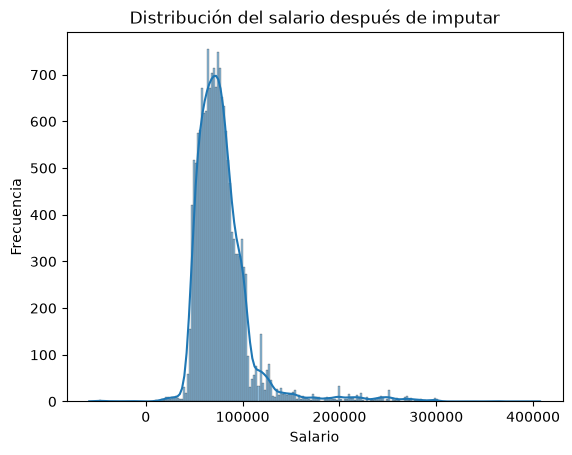

In [90]:
sns.histplot(df_loyalty["Salary"], kde=True)

plt.title("Distribución del salario después de imputar")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

### Unión de ambas tablas

In [63]:
print(f'Tamaño df_activity: {df_activity.shape}')
print(f'Tamaño df_loyalty: {df_loyalty.shape}')

Tamaño df_activity: (405624, 9)
Tamaño df_loyalty: (16737, 15)


In [67]:
df_loyalty.index.duplicated().sum()

np.int64(0)

In [68]:
df_activity.index.duplicated().sum()

np.int64(388887)

In [91]:
df_final = df_activity.merge(df_loyalty, on=['Loyalty Number'], how='left')
df_final.head()

,Year,date,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,...,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Date,Enrollment Year,Cancellation Year,Cancellation Date
Loyalty Number,,,,,,,,,,,,,,,,,,,,,
100018,2017,2017-01-01,3,0,3,1521,152.0,0,0,Canada,...,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016-08-01,2016,<NA>,NaT
100102,2017,2017-01-01,10,4,14,2030,203.0,0,0,Canada,...,College,52948.2,Single,Nova,2887.74,Standard,2013-03-01,2013,<NA>,NaT
100140,2017,2017-01-01,6,0,6,1200,120.0,0,0,Canada,...,College,73130.2,Divorced,Nova,2838.07,Standard,2016-07-01,2016,<NA>,NaT
100214,2017,2017-01-01,0,0,0,0,0.0,0,0,Canada,...,Bachelor,63253.0,Married,Star,4170.57,Standard,2015-08-01,2015,<NA>,NaT
100272,2017,2017-01-01,0,0,0,0,0.0,0,0,Canada,...,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014-01-01,2014,<NA>,NaT


In [92]:
#Unificación nombre columnas

df_final.columns = (
    df_final.columns
    .str.lower()
    .str.replace(" ", "_")
)
df_final.info()

<class 'pandas.DataFrame'>
Index: 405624 entries, 100018 to 999986
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   year                         405624 non-null  int64         
 1   date                         405624 non-null  datetime64[us]
 2   flights_booked               405624 non-null  int64         
 3   flights_with_companions      405624 non-null  int64         
 4   total_flights                405624 non-null  int64         
 5   distance                     405624 non-null  int64         
 6   points_accumulated           405624 non-null  float64       
 7   points_redeemed              405624 non-null  int64         
 8   dollar_cost_points_redeemed  405624 non-null  int64         
 9   country                      405624 non-null  str           
 10  province                     405624 non-null  str           
 11  city                         405624 n

## Gestión de nulos

In [75]:
df_final.isnull().sum()/len(df_final) * 100

year                            0.000000
date                            0.000000
flights_booked                  0.000000
flights_with_companions         0.000000
total_flights                   0.000000
distance                        0.000000
points_accumulated              0.000000
points_redeemed                 0.000000
dollar_cost_points_redeemed     0.000000
country                         0.000000
province                        0.000000
city                            0.000000
postal_code                     0.000000
gender                          0.000000
education                       0.000000
salary                         25.312112
marital_status                  0.000000
loyalty_card                    0.000000
clv                             0.000000
enrollment_type                 0.000000
enrollment_date                 0.000000
enrollment_year                 0.000000
cancellation_year              87.657535
cancellation_date              87.657535
is_cancelled    

In [94]:
# Es probable que haya nulos en la fecha de cancelación porque esos clientes no han cancelado su membresía
# Por ello ni se borran ni se imputan. Creo una nueva columna que indica si ha cancelado o no

df_final["is_cancelled"] = df_final["cancellation_date"].notnull()

In [76]:
df_final

,year,date,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,...,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,enrollment_year,cancellation_year,cancellation_date,is_cancelled
Loyalty Number,,,,,,,,,,,,,,,,,,,,,
100018,2017,2017-01-01,3,0,3,1521,152.0,0,0,Canada,...,92552.0,Married,Aurora,7919.20,Standard,2016-08-01,2016,<NA>,NaT,False
100102,2017,2017-01-01,10,4,14,2030,203.0,0,0,Canada,...,NaN,Single,Nova,2887.74,Standard,2013-03-01,2013,<NA>,NaT,False
100140,2017,2017-01-01,6,0,6,1200,120.0,0,0,Canada,...,NaN,Divorced,Nova,2838.07,Standard,2016-07-01,2016,<NA>,NaT,False
100214,2017,2017-01-01,0,0,0,0,0.0,0,0,Canada,...,63253.0,Married,Star,4170.57,Standard,2015-08-01,2015,<NA>,NaT,False
100272,2017,2017-01-01,0,0,0,0,0.0,0,0,Canada,...,91163.0,Divorced,Star,6622.05,Standard,2014-01-01,2014,<NA>,NaT,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999902,2018,2018-12-01,0,0,0,0,0.0,0,0,Canada,...,NaN,Married,Aurora,7290.07,Standard,2014-05-01,2014,<NA>,NaT,False
999911,2018,2018-12-01,0,0,0,0,0.0,0,0,Canada,...,217943.0,Single,Nova,8564.77,Standard,2012-08-01,2012,<NA>,NaT,False
999940,2018,2018-12-01,3,0,3,1233,123.0,0,0,Canada,...,47670.0,Married,Nova,20266.50,Standard,2017-07-01,2017,<NA>,NaT,False


In [81]:
# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

In [ ]:
#Como el % nulos en salario supera el 20%, usamos algoritmos para imputar los nulos.
#Se hace en el apartado de la tabla loyalty, para imputar los nulos antes de unificar las tablas. Dado que como en la tabla df_activity hay duplicados, podría distorsionar la imputación

df_final.isnull().sum()/len(df_final) * 100

year                            0.000000
date                            0.000000
flights_booked                  0.000000
flights_with_companions         0.000000
total_flights                   0.000000
distance                        0.000000
points_accumulated              0.000000
points_redeemed                 0.000000
dollar_cost_points_redeemed     0.000000
country                         0.000000
province                        0.000000
city                            0.000000
postal_code                     0.000000
gender                          0.000000
education                       0.000000
salary                          0.000000
marital_status                  0.000000
loyalty_card                    0.000000
clv                             0.000000
enrollment_type                 0.000000
enrollment_date                 0.000000
enrollment_year                 0.000000
cancellation_year              87.657535
cancellation_date              87.657535
is_cancelled    

### Limpieza variables categóricas


In [100]:
df_final['province'].unique()

<StringArray>
[             'Alberta',              'Ontario',     'British Columbia',
         'Saskatchewan',               'Quebec',         'Newfoundland',
             'Manitoba',        'New Brunswick',          'Nova Scotia',
 'Prince Edward Island',                'Yukon']
Length: 11, dtype: str

In [101]:
df_final['country'].unique()

<StringArray>
['Canada']
Length: 1, dtype: str

In [102]:
df_final['city'].unique()

<StringArray>
[      'Edmonton',        'Toronto',   'Dawson Creek',      'Vancouver',
         'Regina',       'Montreal',        'Sudbury',    'Quebec City',
    'Peace River',     'St. John's',      'Tremblant',         'Ottawa',
        'Trenton',       'Winnipeg',    'Thunder Bay', 'West Vancouver',
    'Fredericton',         'London',        'Halifax',        'Moncton',
          'Banff',       'Kingston',       'Whistler',  'Charlottetown',
           'Hull',       'Victoria',        'Calgary',        'Kelowna',
     'Whitehorse']
Length: 29, dtype: str

In [103]:
df_final['postal_code'].unique()

<StringArray>
['T9G 1W3', 'M1R 4K3', 'U5I 4F1', 'V5R 1W3', 'P1L 8X8', 'P1J 8T7', 'S6J 3G0',
 'H2T 9K8', 'V6E 3D9', 'M5V 1G5', 'H2Y 4R4', 'M8Y 4K8', 'V6E 3Z3', 'G1B 3L5',
 'T9O 2W2', 'A1C 6H9', 'H5Y 2S9', 'K1F 2R2', 'K8V 4B2', 'R3R 3T4', 'P1W 1K4',
 'K8T 5M5', 'V6V 8Z3', 'M2M 7K8', 'E3B 2H2', 'M5B 3E4', 'H2Y 2W2', 'P5S 6R4',
 'P2T 6G3', 'B3J 9S2', 'B3C 2M8', 'H4G 3T4', 'R6Y 4T5', 'H2T 2J6', 'M2Z 4K1',
 'S1J 3C5', 'E1A 2A7', 'V1E 4R6', 'T4V 1D4', 'M9K 2P4', 'R2C 0M5', 'T3G 6Y6',
 'M2M 6J7', 'V6T 1Y8', 'C1A 6E8', 'J8Y 3Z5', 'V10 6T5', 'H3T 8L4', 'T3E 2V9',
 'V09 2E9', 'Y2K 6R0', 'K1G 4Z0', 'M2P 4F6', 'M3R 4K8', 'H3J 5I6']
Length: 55, dtype: str

In [104]:
df_final['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [ ]:
df_final['education'].unique()


<StringArray>
['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor']
Length: 5, dtype: str

In [106]:
df_final['marital_status'].unique()

<StringArray>
['Married', 'Single', 'Divorced']
Length: 3, dtype: str

In [107]:
df_final['loyalty_card'].unique()

<StringArray>
['Aurora', 'Nova', 'Star']
Length: 3, dtype: str

In [108]:
df_final['enrollment_type'].unique()

<StringArray>
['Standard', '2018 Promotion']
Length: 2, dtype: str

In [96]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 405624 entries, 100018 to 999986
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   year                         405624 non-null  int64         
 1   date                         405624 non-null  datetime64[us]
 2   flights_booked               405624 non-null  int64         
 3   flights_with_companions      405624 non-null  int64         
 4   total_flights                405624 non-null  int64         
 5   distance                     405624 non-null  int64         
 6   points_accumulated           405624 non-null  float64       
 7   points_redeemed              405624 non-null  int64         
 8   dollar_cost_points_redeemed  405624 non-null  int64         
 9   country                      405624 non-null  str           
 10  province                     405624 non-null  str           
 11  city                         405624 n